In [ ]:
import nbformat
from nbconvert import PythonExporter

notebook_path = '/content/drive/MyDrive/FWI/Forward_modelling.ipynb'
output_script_path = '/content/Forward_modelling.py'

with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook_content = nbformat.read(f, as_version=4)
exporter = PythonExporter()
python_code, _ = exporter.from_notebook_node(notebook_content)
with open(output_script_path, 'w', encoding='utf-8') as f:
    f.write(python_code)

In [ ]:
import sys
sys.path.append('/content/Forward_modelling')



In [ ]:
import Forward_modelling
from Forward_modelling import helmholtz5

In [ ]:

import nbformat
from nbconvert import PythonExporter

notebook_path = '/content/drive/MyDrive/FWI/Inversion.ipynb'
output_script_path = '/content/Inversion.py'

with open(notebook_path, 'r', encoding='utf-8') as f:
    notebook_content = nbformat.read(f, as_version=4)
exporter = PythonExporter()
python_code, _ = exporter.from_notebook_node(notebook_content)
with open(output_script_path, 'w', encoding='utf-8') as f:
    f.write(python_code)

In [ ]:
from Inversion import Gauss_newton

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter


In [ ]:
# import numpy as np
# import matplotlib.pyplot as plt



# filename = "vp.bin"

# nx_m, nz_m = 751, 2301
# data = np.fromfile(filename, dtype='<f4')

# expected_total_elements = nz_m * nx_m
# actual_total_elements = len(data)


# model = data.reshape((nz_m, nx_m)).T

# # ---- plot ----
# plt.imshow(model, cmap='jet', aspect='auto')
# plt.colorbar(label="Velocity (m/s)")
# plt.xlabel("X")
# plt.ylabel("Z")
# plt.title("Marmousi Model")
# plt.show()

In [ ]:
# ==========================================================
#  GRID
# ==========================================================
nx, nz = 200, 150
dx = dz = 10
n = nx * nz
npml = 10

idx = lambda i, j: i * nx + j

# ==========================================================
# SOURCES & RECEIVERS
# ==========================================================
nsrc = 15
src_x = np.linspace(10, nx-15, nsrc).astype(int)
src_z = 15


# Receiver x positions
rec_x = np.arange(10, 70,2)
rec_z = 15
#rec_idx = [idx(15,i) for i in range(10,70)]
rec_idx = [idx(rec_z, x) for x in rec_x]
nrec = len(rec_idx)


# Source physical positions

x_phys = np.arange(nx) * dx
z_phys = np.arange(nz) * dz

src_x_phys = src_x * dx
src_z_phys = src_z * dz

rec_x_phys = rec_x * dx
rec_z_phys = rec_z * dz

model_extent = [x_phys[0], x_phys[-1], z_phys[-1], z_phys[0]]


In [ ]:
#==========================================================
#TRUE MODEL (Marmousi)
#==========================================================

#---- read Marmousi ----
filename = "vp.bin"
nx_m, nz_m = 751, 2301

marm = np.fromfile(filename, dtype='<f4')
marm = marm.reshape((nz_m, nx_m)).T

# ---- crop central part  ----
marm = marm[100:600, 300:2000]

# ---- resample to 80x80 grid ----
from scipy.ndimage import zoom

scale_z = nz / marm.shape[0]
scale_x = nx / marm.shape[1]

c_true = zoom(marm, (scale_z, scale_x))


c_init = gaussian_filter(c_true, sigma=10)


m_true = 1 / c_true**2
m = 1 / c_init**2


plt.imshow(c_init,cmap='jet',extent=model_extent)
plt.title("True velocity model")
plt.xlabel("Distance (meters)")
plt.ylabel("Depth (meters)")
plt.colorbar(label="velocity (m/s)")
plt.show()

FileNotFoundError: [Errno 2] No such file or directory: 'vp.bin'

In [ ]:
frequencies = [3,4,5,6,7]
# initial LM damping
beta0 =10   #1e-3

# regularization
alpha =  5e-5

vmax=6000

In [ ]:


# ==========================================================
# OBSERVED DATA
# Generate d_obs using the TRUE model
# ==========================================================


#projetion operator

P = sp.lil_matrix((nrec,n))
for i,r in enumerate(rec_idx):
    P[i,r]=1
P = P.tocsr()

d_obs = {}

for f in frequencies:
    omega = 2*np.pi*f
    #weight = (f**2 / f0**2) * np.exp(-f**2 / f0**2)
    d_obs[f] = []

    A =Forward_modelling.helmholtz5(m_true,omega,dx,dz,npml,vmax)
    LU = spla.splu(A.tocsc())

    for s in src_x:
        q = np.zeros(n,dtype=complex)
        q[idx(src_z,s)] = 1.0
        u = LU.solve(q)
        d_obs[f].append(P@u)   #*weight

In [ ]:
m_gn, misfits_gn=Gauss_newton(c_init, frequencies, d_obs,
                         P, rec_idx,
                        src_x, src_z,
                        nx, nz, n, idx,
                        dx,dz,npml,vmax,
                        alpha,
                        n_iterations=12,
                        cg_maxiter=40)


===== Frequency: 3 Hz =====
Iteration: 1 Misfit: 11418.801695263463
Iteration: 2 Misfit: 8392.07553645621
Iteration: 3 Misfit: 1466.1053149146514
Iteration: 4 Misfit: 28.71737127292367
Iteration: 5 Misfit: 1.7493090012684147
Iteration: 6 Misfit: 1.6258074870600645
Iteration: 7 Misfit: 1.4554625564166326
Iteration: 8 Misfit: 1.3241508365057777
Iteration: 9 Misfit: 1.2243674113872878
Iteration: 10 Misfit: 1.1447980648878662
Iteration: 11 Misfit: 1.0789004368752304
Iteration: 12 Misfit: 1.029637759943031

===== Frequency: 4 Hz =====
Iteration: 1 Misfit: 12764.473317221127
Iteration: 2 Misfit: 3673.1631599403663
Iteration: 3 Misfit: 923.1300725054423
Iteration: 4 Misfit: 79.3911015208355
Iteration: 5 Misfit: 1.9450220048670093
Iteration: 6 Misfit: 0.9474132124806772
Iteration: 7 Misfit: 0.8839246387589907
Iteration: 8 Misfit: 0.8630976935952588
Iteration: 9 Misfit: 0.8427570664229939
Iteration: 10 Misfit: 0.834302705783006
Iteration: 11 Misfit: 0.8236345925542571
Iteration: 12 Misfit: 0.8

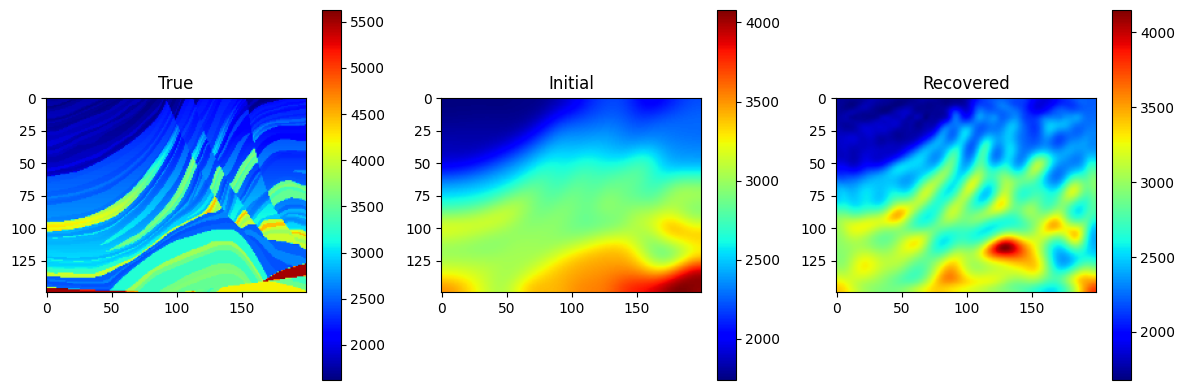

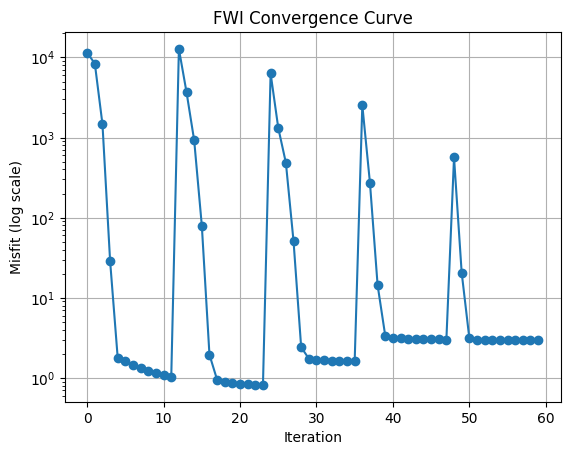

In [ ]:
# ==========================================================
# 9. RESULTS
# ==========================================================
plt.figure(figsize=(12,4))

plt.subplot(131)
plt.title("True")
plt.imshow(c_true,cmap='jet')
plt.colorbar()

plt.subplot(132)
plt.title("Initial")
plt.imshow(c_init,cmap='jet')
plt.colorbar()

plt.subplot(133)
plt.title("Recovered")
plt.imshow(1/np.sqrt(m_gn),cmap='jet')
plt.colorbar()

plt.tight_layout()
plt.show()

# ==========================================================
# 10. CONVERGENCE CURVE (THESIS FIGURE)
# ==========================================================
plt.figure()
plt.semilogy(misfits_gn,'-o')
plt.xlabel("Iteration")
plt.ylabel("Misfit (log scale)")
plt.title("FWI Convergence Curve")
plt.grid()
plt.show()


===== Frequency: 3 Hz ====
Iteration: 1 Misfit: 77240.0979370269
Iteration: 2 Misfit: 6985.945135189372
Iteration: 3 Misfit: 66.95346100361058
Iteration: 4 Misfit: 17.70355398396216
Iteration: 5 Misfit: 11.262194461473863
Iteration: 6 Misfit: 9.93543740551438
Iteration: 7 Misfit: 9.113777869726615
Iteration: 8 Misfit: 8.405861146002662
Iteration: 9 Misfit: 8.136457781741568
Iteration: 10 Misfit: 7.767323035304368
Iteration: 11 Misfit: 7.633795327659037
Iteration: 12 Misfit: 7.43043886829329

===== Frequency: 5 Hz ====
Iteration: 1 Misfit: 4546.699339641062
Iteration: 2 Misfit: 161.96434650272664
Iteration: 3 Misfit: 9.101032433146674
Iteration: 4 Misfit: 8.18452084297725
Iteration: 5 Misfit: 8.042993523047977
Iteration: 6 Misfit: 8.135135318851958
Iteration: 7 Misfit: 8.15902021334979
Iteration: 8 Misfit: 8.172182185442628
Iteration: 9 Misfit: 8.206874438361162
Iteration: 10 Misfit: 8.193772731129037
Iteration: 11 Misfit: 8.233189393522238
Iteration: 12 Misfit: 8.161168453834442

====

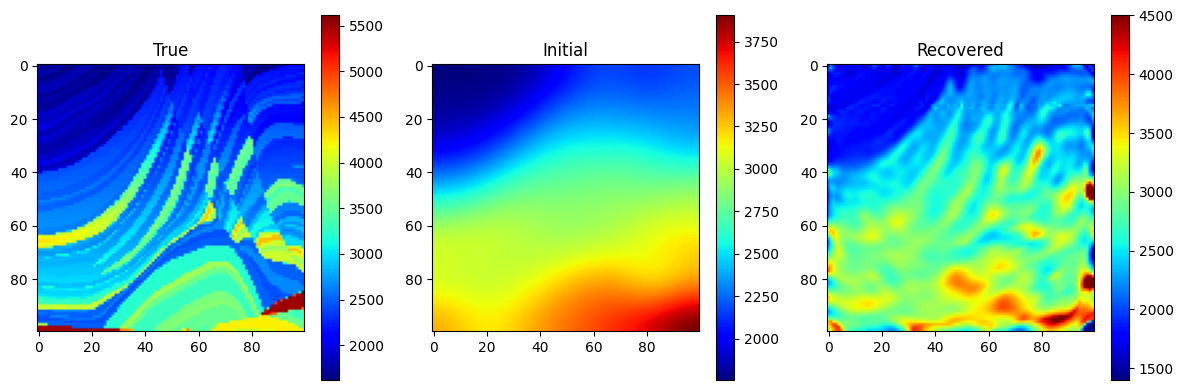

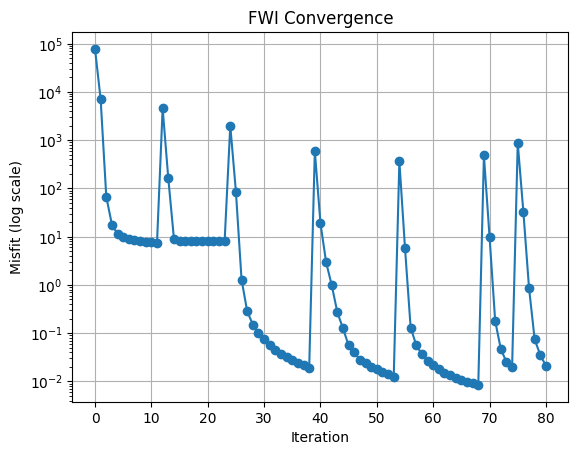

In [ ]:
import numpy as np
import scipy.sparse as sp
import scipy.sparse.linalg as spla
import matplotlib.pyplot as plt
from scipy.ndimage import gaussian_filter, zoom

# ==========================================================
# 1. GRID
# ==========================================================
#nx, nz = 200,150
nx, nz =100,100
dx = dz = 10.0
n = nx * nz
npml = 10

idx = lambda i, j: i * nx + j

# ==========================================================
# 2. TRUE MODEL (Marmousi)
# ==========================================================
filename = "vp.bin"
nx_m, nz_m = 751, 2301

marm = np.fromfile(filename, dtype='<f4')
marm = marm.reshape((nz_m, nx_m)).T
marm = marm[100:600, 300:2000]

scale_z = nz / marm.shape[0]
scale_x = nx / marm.shape[1]
c_true = zoom(marm, (scale_z, scale_x))

c_init = gaussian_filter(c_true, sigma=10)

m_true = 1 / c_true**2
m = 1 / c_init**2

# ==========================================================
# 3. PML
# ==========================================================
def pml_sigma(n, npml, dx, vmax):
    sigma = np.zeros(n)
    sigma_max = 3*vmax*np.log(100)/(2*npml*dx)
    for i in range(npml):
        x = (npml-i)/npml
        sigma[i] = sigma_max*x**2
        sigma[n-1-i] = sigma_max*x**2
    return sigma

sigma_x = pml_sigma(nx, npml, dx, 4500)
sigma_z = pml_sigma(nz, npml, dz, 4500)

# ==========================================================
# 4. HELMHOLTZ
# ==========================================================
def build_helmholtz(m, omega):

    rows, cols, data = [], [], []

    for i in range(nz):
        for j in range(nx):

            k = idx(i,j)

            sx = 1 + 1j*sigma_x[j]/omega
            sz = 1 + 1j*sigma_z[i]/omega

            ax = 1/(sx*dx**2)
            az = 1/(sz*dz**2)

            main = -2*ax - 2*az + omega**2*m[i,j]

            rows.append(k); cols.append(k); data.append(main)

            if j>0:
                rows.append(k); cols.append(idx(i,j-1)); data.append(ax)
            if j<nx-1:
                rows.append(k); cols.append(idx(i,j+1)); data.append(ax)
            if i>0:
                rows.append(k); cols.append(idx(i-1,j)); data.append(az)
            if i<nz-1:
                rows.append(k); cols.append(idx(i+1,j)); data.append(az)

    return sp.coo_matrix((data,(rows,cols)),shape=(n,n)).tocsr()

# ==========================================================
# 5. SOURCES & RECEIVERS (Improved coverage)
# ==========================================================
nsrc = 15
src_x = np.linspace(15, nx-15, nsrc).astype(int)
src_z = 15

rec_idx = [idx(15,i) for i in range(5,115)]
nrec = len(rec_idx)

P = sp.lil_matrix((nrec,n))
for i,r in enumerate(rec_idx):
    P[i,r]=1
P = P.tocsr()

# ==========================================================
# 6. FREQUENCIES (Multiscale)
# ==========================================================
frequencies = [3,5,7,10,12,15,18]

# ==========================================================
# 7. OBSERVED DATA
# ==========================================================
d_obs = {}

for f in frequencies:
    omega = 2*np.pi*f
    d_obs[f] = []

    A = build_helmholtz(m_true, omega)
    LU = spla.splu(A.tocsc())

    for s in src_x:
        q = np.zeros(n,dtype=complex)
        q[idx(src_z,s)] = 1.0
        u = LU.solve(q)
        d_obs[f].append(P@u)

# ==========================================================
# 8. FWI
# ==========================================================
misfits = []

for f in frequencies:

    print("\n===== Frequency:",f,"Hz ====")
    omega = 2*np.pi*f

    # Iteration schedule
    if f <= 6:
        niter = 12
    elif f <= 12:
        niter = 15
    else:
        niter = 6

    # Frequency-dependent regularization
    alpha = 5e-5/(f**2)

    for iteration in range(niter):

        g_total = np.zeros(n)
        H_data = []

        A = build_helmholtz(m, omega)
        LU = spla.splu(A.tocsc())

        misfit = 0

        for isrc,s in enumerate(src_x):

            q = np.zeros(n,dtype=complex)
            q[idx(src_z,s)] = 1.0

            u = LU.solve(q)
            r = P@u - d_obs[f][isrc]
            misfit += 0.5*np.linalg.norm(r)**2

            rhs = np.zeros(n,dtype=complex)
            rhs[rec_idx] = r
            lam = LU.solve(rhs,trans='H')

            g_total += -omega**2*np.real(u.conj()*lam)
            H_data.append((u, LU))

        misfits.append(misfit)
        print("Iteration:",iteration+1,"Misfit:",misfit)

        # ---- Hessian diagonal (illumination preconditioner)
        diagH = np.zeros(n)
        for (u, LU) in H_data:
            diagH += omega**4 * np.abs(u)**2
        diagH += alpha

        # ---- Hessian-vector product
        def H_matvec(v):
            Hv = np.zeros(n)
            for (u, LU) in H_data:
                w = LU.solve(-omega**2*(v*u))
                Jv = P@w
                rhs2 = np.zeros(n,dtype=complex)
                rhs2[rec_idx] = Jv
                lam2 = LU.solve(rhs2,trans='H')
                Hv += -omega**2*np.real(u.conj()*lam2)
            Hv += alpha*v
            return Hv

        H_linop = spla.LinearOperator((n,n),matvec=H_matvec)

        # ---- Preconditioner
        def M_inv(v):
            return v/(diagH+1e-8)

        M_linop = spla.LinearOperator((n,n),matvec=M_inv)

        # Increase CG at high frequency
        cg_iter = 40 if f<=12 else 60

        dm,info = spla.cg(H_linop,-g_total,
                          maxiter=cg_iter,
                          rtol=1e-6,
                          M=M_linop)

        # ---- Line search
        step = 1.0
        for _ in range(8):
            m_trial = m + step*dm.reshape(nz,nx)
            A_trial = build_helmholtz(m_trial, omega)
            LU_trial = spla.splu(A_trial.tocsc())

            misfit_trial = 0
            for isrc,s in enumerate(src_x):
                q = np.zeros(n,dtype=complex)
                q[idx(src_z,s)] = 1.0
                u_trial = LU_trial.solve(q)
                r_trial = P@u_trial - d_obs[f][isrc]
                misfit_trial += 0.5*np.linalg.norm(r_trial)**2

            if misfit_trial < misfit:
                break
            step *= 0.5

        m += step*dm.reshape(nz,nx)

        # Low-frequency stabilization only
        if f <= 6:
            m = gaussian_filter(m, sigma=1)

        # Velocity clipping (convert to m_min and m_max and clip m directly)
        # Ensure m remains positive before sqrt, and within physical bounds
        m_min = 1.0 / (4500**2) # m_max corresponds to v_min
        m_max = 1.0 / (1400**2) # m_min corresponds to v_max

        # Clip m directly to prevent negative values and ensure physical bounds
        m = np.clip(m, m_min, m_max)

# ==========================================================
# 9. RESULTS
# ==========================================================
plt.figure(figsize=(12,4))

plt.subplot(131)
plt.title("True")
plt.imshow(c_true,cmap='jet')
plt.colorbar()

plt.subplot(132)
plt.title("Initial")
plt.imshow(c_init,cmap='jet')
plt.colorbar()

plt.subplot(133)
plt.title("Recovered")
plt.imshow(1/np.sqrt(m),cmap='jet')
plt.colorbar()

plt.tight_layout()
plt.show()

plt.figure()
plt.semilogy(misfits,'-o')
plt.xlabel("Iteration")
plt.ylabel("Misfit (log scale)")
plt.title("FWI Convergence")
plt.grid()
plt.show()